In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
rnn_model = models.Sequential()

rnn_model.add(layers.Embedding(vocab_size, 128, input_length=max_len))
rnn_model.add(layers.SimpleRNN(64))
rnn_model.add(layers.Dense(32, activation='relu'))
rnn_model.add(layers.Dense(1, activation='sigmoid'))

rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.7035 - loss: 0.5423 - val_accuracy: 0.7920 - val_loss: 0.4450
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.8415 - loss: 0.3680 - val_accuracy: 0.8007 - val_loss: 0.4457
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.8981 - loss: 0.2535 - val_accuracy: 0.8238 - val_loss: 0.4322


In [ ]:
lstm_model = models.Sequential()

lstm_model.add(layers.Embedding(vocab_size, 128, input_length=max_len))
lstm_model.add(layers.LSTM(64))
lstm_model.add(layers.Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 127s 316ms/step - accuracy: 0.7927 - loss: 0.4346 - val_accuracy: 0.8552 - val_loss: 0.3397
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 125s 319ms/step - accuracy: 0.8978 - loss: 0.2609 - val_accuracy: 0.8556 - val_loss: 0.3347
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 139s 313ms/step - accuracy: 0.9320 - loss: 0.1814 - val_accuracy: 0.8707 - val_loss: 0.3357


In [ ]:
gru_model = models.Sequential()

gru_model.add(layers.Embedding(vocab_size, 128, input_length=max_len))
gru_model.add(layers.GRU(64))
gru_model.add(layers.Dense(1, activation='sigmoid'))

gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

gru_history = gru_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 131s 327ms/step - accuracy: 0.7874 - loss: 0.4388 - val_accuracy: 0.8604 - val_loss: 0.3296
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 125s 321ms/step - accuracy: 0.9011 - loss: 0.2518 - val_accuracy: 0.8730 - val_loss: 0.3103
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 127s 324ms/step - accuracy: 0.9374 - loss: 0.1688 - val_accuracy: 0.8656 - val_loss: 0.3514


782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8238 - loss: 0.4322
RNN Test Accuracy: 0.8238000273704529
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8707 - loss: 0.3357
LSTM Test Accuracy: 0.8706799745559692
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8656 - loss: 0.3514
GRU Test Accuracy: 0.8655999898910522


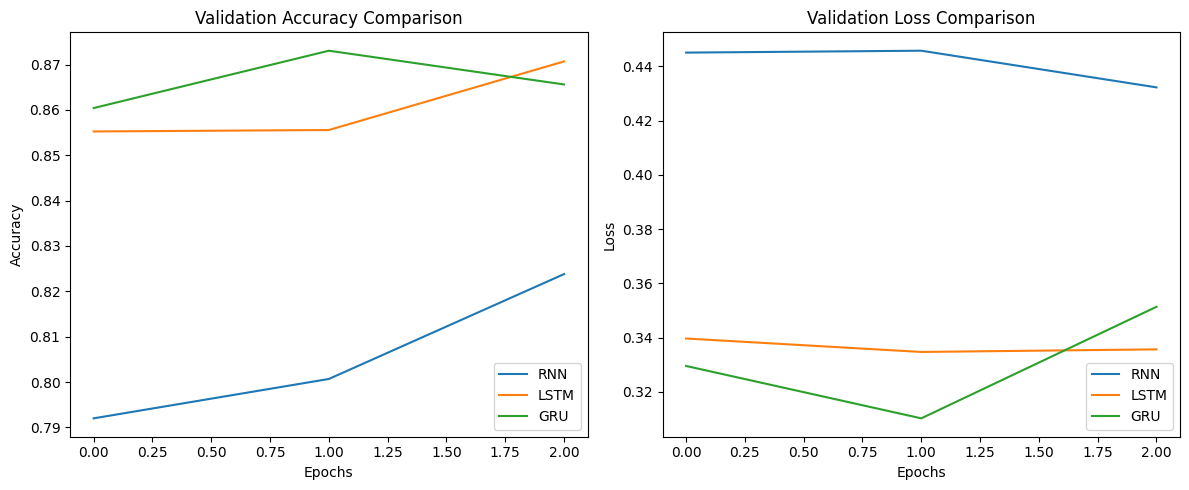

In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(x_test, y_test)
print("RNN Test Accuracy:", rnn_acc)

lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test)
print("LSTM Test Accuracy:", lstm_acc)

gru_loss, gru_acc = gru_model.evaluate(x_test, y_test)
print("GRU Test Accuracy:", gru_acc)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(rnn_history.history['val_loss'], label='RNN')
plt.plot(lstm_history.history['val_loss'], label='LSTM')
plt.plot(gru_history.history['val_loss'], label='GRU')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()